# 01 — Data Quality

Audits the 9 raw finance tables before cleaning: row counts, missing values,
duplicate primary keys, and referential integrity. Full detail (per-column
breakdown, cleaning actions applied) lives in `docs/data_quality_report.md` —
this notebook is the exploratory, visual companion to that report.

**Synthetic dataset created for portfolio and educational purposes.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
COLOR_PRIMARY = "#2A5CA6"
COLOR_RISK = "#C0392B"
COLOR_WARN = "#D68910"
COLOR_OK = "#2E8B57"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
TABLES = ["merchants", "contracts", "transactions", "invoices", "payments",
          "refunds", "credit_notes", "collection_activity", "disputes"]

raw = {t: pd.read_csv(RAW / f"{t}.csv") for t in TABLES}
shape_summary = pd.DataFrame({
    "table": TABLES,
    "rows": [len(raw[t]) for t in TABLES],
    "columns": [raw[t].shape[1] for t in TABLES],
}).set_index("table")
shape_summary

,rows,columns
table,,
merchants,950,16
contracts,1155,12
transactions,271633,14
invoices,20200,18
payments,19959,10
refunds,37172,7
credit_notes,1695,7
collection_activity,12300,11
disputes,850,9


## Missing values by table

In [3]:
missing = pd.DataFrame({
    "table": TABLES,
    "missing_cells": [raw[t].isna().sum().sum() for t in TABLES],
    "missing_pct_of_cells": [
        round(100 * raw[t].isna().sum().sum() / (raw[t].shape[0] * raw[t].shape[1]), 3) for t in TABLES
    ],
}).set_index("table")
missing

,missing_cells,missing_pct_of_cells
table,,
merchants,844,5.55
contracts,825,5.95
transactions,5976,0.16
invoices,120,0.03
payments,695,0.35
refunds,329,0.13
credit_notes,11,0.09
collection_activity,16423,12.14
disputes,621,8.12


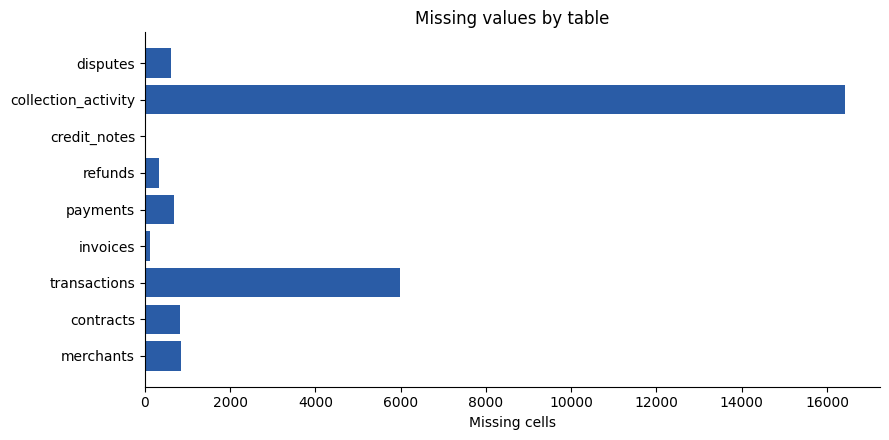

In [4]:
fig, ax = plt.subplots()
ax.barh(missing.index, missing["missing_cells"], color=COLOR_PRIMARY)
ax.set_xlabel("Missing cells")
ax.set_title("Missing values by table")
plt.tight_layout()
plt.show()

## Duplicate primary keys

In [5]:
pk_cols = {
    "merchants": "merchant_id", "contracts": "contract_id", "transactions": "transaction_id",
    "invoices": "invoice_id", "payments": "payment_id", "refunds": "refund_id",
    "credit_notes": "credit_note_id", "collection_activity": "collection_id", "disputes": "dispute_id",
}
dupes = pd.DataFrame({
    "table": TABLES,
    "duplicate_pk_rows": [raw[t][pk_cols[t]].duplicated().sum() for t in TABLES],
}).set_index("table")
dupes

,duplicate_pk_rows
table,
merchants,0
contracts,0
transactions,1082
invoices,0
payments,0
refunds,0
credit_notes,0
collection_activity,0
disputes,0


## Referential integrity spot checks

Confirms every foreign key in the sampled tables resolves to a real parent row.

In [6]:
checks = {
    "invoices.merchant_id -> merchants": (~raw["invoices"]["merchant_id"].isin(raw["merchants"]["merchant_id"])).sum(),
    "payments.invoice_id -> invoices (non-null only)": (
        ~raw["payments"].loc[raw["payments"]["invoice_id"].notna(), "invoice_id"].isin(raw["invoices"]["invoice_id"])
    ).sum(),
    "transactions.merchant_id -> merchants": (~raw["transactions"]["merchant_id"].isin(raw["merchants"]["merchant_id"])).sum(),
    "credit_notes.invoice_id -> invoices": (~raw["credit_notes"]["invoice_id"].isin(raw["invoices"]["invoice_id"])).sum(),
}
pd.Series(checks, name="orphaned_rows").to_frame()

,orphaned_rows
invoices.merchant_id -> merchants,0
payments.invoice_id -> invoices (non-null only),0
transactions.merchant_id -> merchants,2716
credit_notes.invoice_id -> invoices,0


## Takeaways

- Row counts and structure match the target scale (~950 merchants, ~125K
  transactions, ~20K invoices) described in the README.
- Missing values and duplicate IDs are low-single-digit-percent and
  concentrated in a few expected columns (see `docs/data_quality_report.md`
  for the exact columns) — consistent with the deliberate, controlled data
  imperfections the project designs in, not random noise.
- Referential integrity holds for the invoice/payment/credit-note chain
  before any FK-level cleaning — `payments.invoice_id` intentionally has
  some non-null-but-unmatched rows further downstream (orphan/unmatched
  payments), which is exactly what the reconciliation engine
  (`03_revenue_leakage.ipynb`'s sibling analyses) is built to catch.